In [1]:
import pandas as pd
import pathlib
import re
import json
import numpy as np

import seaborn as sns
from upsetplot import from_indicators, plot
import matplotlib.pyplot as plt
from functools import reduce

import warnings

# Ignore upset plot warning regarding  behavior change that will occur in pandas 3.0
warnings.filterwarnings("ignore", category=FutureWarning, module="upsetplot")

In [2]:
# Set constants for prefixes we want to keep for the dataframes
prefixes = ("Metadata_", "ImageQuality_PercentMaximal", "ImageQuality_PowerLogLogSlope")

# Set directory with the blur threshold files
blur_thresholds_dir = pathlib.Path("./blur_thresholds/")

# Output directory for plots
output_directory = pathlib.Path("./qc_plots")
output_directory.mkdir(exist_ok=True)

# path to the qc results
qc_results = pathlib.Path("./qc_results/")
# Find all Image.csv files in the directory
csv_files = list(qc_results.rglob("Image.csv"))
print(f"Found {len(csv_files)} CSV files.")

Found 44 CSV files.


In [3]:
# For each image.csv file, read it in and add a column for platemap_layout and add the name of the parent to the folder it is in (e.g., platemap_#)
dataframes = []
for csv_file in csv_files:
    df = pd.read_csv(csv_file)
    # Add a column for the platemap layout using the parent of the parent directory
    df["platemap_layout"] = csv_file.parent.parent.name
    dataframes.append(df)

# Concatenate all the dataframes together
qc_df = pd.concat(dataframes, ignore_index=True)
print(f"Concatenated dataframe has {qc_df.shape[0]} rows and {qc_df.shape[1]} columns.")

# Print the unique platemap layouts
print(f"Unique platemap layouts: {qc_df['platemap_layout'].unique()}")

Concatenated dataframe has 63800 rows and 101 columns.
Unique platemap layouts: ['platemap_11' 'platemap_9' 'platemap_3' 'platemap_7' 'platemap_10'
 'platemap_4' 'platemap_1' 'platemap_6' 'platemap_5' 'platemap_8'
 'platemap_2']


In [4]:
# --- Add alias plate name ---
alias_mapping = {}
for layout, group in qc_df.groupby("platemap_layout"):
    layout_number = layout.split("_")[-1]  # e.g. 'platemap_1' -> '1'

    # Extract numeric suffix from plate name (after last underscore)
    plate_order = sorted(
        group["Metadata_Plate"].unique(), key=lambda x: int(x.split("_")[-1])
    )
    letters = [chr(ord("A") + i) for i in range(len(plate_order))]  # A, B, C, D, etc.

    layout_aliases = {
        plate: f"{layout_number}{letter}" for plate, letter in zip(plate_order, letters)
    }
    alias_mapping.update(layout_aliases)

qc_df["plate_alias"] = qc_df["Metadata_Plate"].map(alias_mapping)

print("\nPlate alias mapping:")
for plate, alias in alias_mapping.items():
    print(f"{plate} → {alias}")


Plate alias mapping:
CARD-CelIns-CX7_251023210001 → 1A
CARD-CelIns-CX7_251124150001 → 1B
CARD-CelIns-CX7_251125110001 → 1C
CARD-CelIns-CX7_251126130001 → 1D
CARD-CelIns-CX7_260110170001 → 10A
CARD-CelIns-CX7_260111110001 → 10B
CARD-CelIns-CX7_260112100001 → 10C
CARD-CelIns-CX7_260113090001 → 10D
CARD-CelIns-CX7_260113180001 → 11A
CARD-CelIns-CX7_260114100001 → 11B
CARD-CelIns-CX7_260114180001 → 11C
CARD-CelIns-CX7_260115110001 → 11D
CARD-CelIns-CX7_251130110002 → 2A
CARD-CelIns-CX7_251201110001 → 2B
CARD-CelIns-CX7_251201190001 → 2C
CARD-CelIns-CX7_251202100001 → 2D
CARD-CelIns-CX7_251203170001 → 3A
CARD-CelIns-CX7_251205100001 → 3B
CARD-CelIns-CX7_251208160001 → 3C
CARD-CelIns-CX7_251210180001 → 3D
CARD-CelIns-CX7_251211180001 → 4A
CARD-CelIns-CX7_251212100001 → 4B
CARD-CelIns-CX7_251212180001 → 4C
CARD-CelIns-CX7_251213150001 → 4D
CARD-CelIns-CX7_251215090001 → 4E
CARD-CelIns-CX7_251215140002 → 5A
CARD-CelIns-CX7_251216110001 → 5B
CARD-CelIns-CX7_251216180001 → 5C
CARD-CelIns-CX7_25

In [5]:
# Initialize QC columns
qc_df["fails_blur_threshold"] = False
qc_df["fails_saturation"] = False
qc_df["blur_failed_channels"] = ""  # will store comma-separated channels
qc_df["sat_failed_channels"] = ""  # will store comma-separated channels

saturation_thresh = 1  # 1%

for layout in qc_df["platemap_layout"].unique():
    json_file = blur_thresholds_dir / f"blur_thresholds_{layout}.json"
    if json_file.exists():
        with open(json_file) as f:
            blur_thresholds = json.load(
                f
            )  # dict: {"OrigActin": -2, "OrigDNA": -2.6, ...}

        for channel, blur_thresh in blur_thresholds.items():
            blur_col = f"ImageQuality_PowerLogLogSlope_{channel}"
            sat_col = f"ImageQuality_PercentMaximal_{channel}"  # per-channel saturation

            # Check blur
            if blur_col in qc_df.columns:
                mask_blur = (qc_df["platemap_layout"] == layout) & (
                    qc_df[blur_col] < blur_thresh
                )
                qc_df.loc[mask_blur, "fails_blur_threshold"] = True

                # Append channel to blur_failed_channels
                qc_df.loc[mask_blur, "blur_failed_channels"] = qc_df.loc[
                    mask_blur, "blur_failed_channels"
                ].apply(lambda x: f"{x},{channel}" if x else channel)
                qc_df.loc[
                    qc_df["platemap_layout"] == layout, f"blur_threshold_{channel}"
                ] = blur_thresh

            # Check saturation
            if sat_col in qc_df.columns:
                mask_sat = (qc_df["platemap_layout"] == layout) & (
                    qc_df[sat_col] > saturation_thresh
                )
                qc_df.loc[mask_sat, "fails_saturation"] = True

                # Append channel to sat_failed_channels
                qc_df.loc[mask_sat, "sat_failed_channels"] = qc_df.loc[
                    mask_sat, "sat_failed_channels"
                ].apply(lambda x: f"{x},{channel}" if x else channel)
                qc_df.loc[
                    qc_df["platemap_layout"] == layout,
                    f"saturation_threshold_{channel}",
                ] = saturation_thresh
    else:
        print(f"Warning: No blur threshold found for layout {layout}. Skipping.")

# Totals
num_fail_blur = qc_df["fails_blur_threshold"].sum()
num_fail_sat = qc_df["fails_saturation"].sum()
print(f"Total images that fail blur threshold: {num_fail_blur}")
print(
    f"Total images that fail saturation threshold (> {saturation_thresh}): {num_fail_sat}"
)

Total images that fail blur threshold: 2492
Total images that fail saturation threshold (> 1): 607


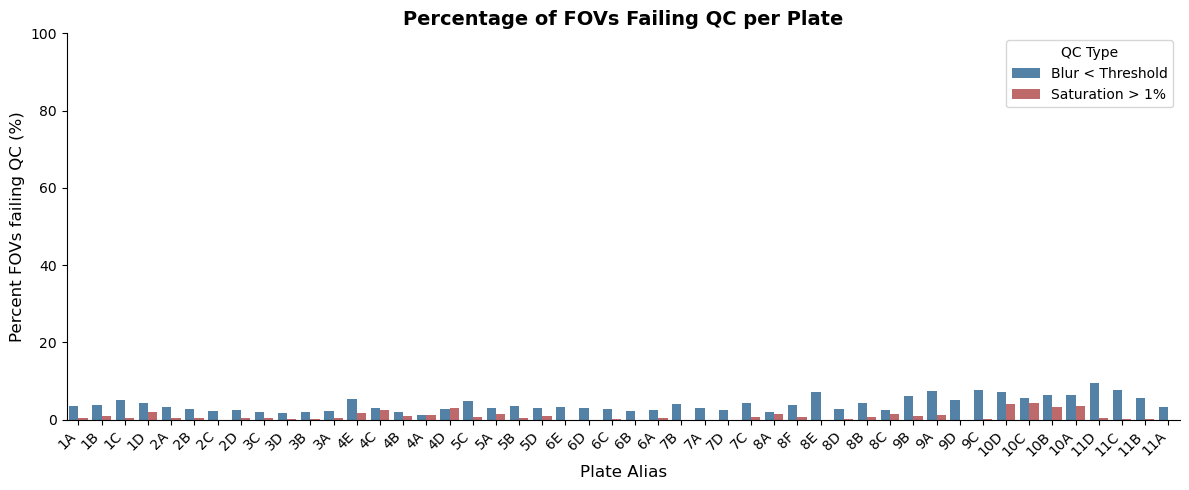

In [6]:
# Compute failure percentage per plate for both blur and saturation
fail_summary = qc_df.groupby("plate_alias", as_index=False).agg(
    total_images=("fails_blur_threshold", "size"),
    failed_blur=("fails_blur_threshold", "sum"),
    failed_sat=("fails_saturation", "sum"),
)
fail_summary["percent_blur_failed"] = (
    fail_summary["failed_blur"] / fail_summary["total_images"] * 100
)
fail_summary["percent_sat_failed"] = (
    fail_summary["failed_sat"] / fail_summary["total_images"] * 100
)

# Sort plate_alias numerically
fail_summary = fail_summary.sort_values(
    by="plate_alias", key=lambda x: x.str.extract(r"(\d+)").iloc[:, 0].astype(int)
)

# Melt for seaborn grouped bar plot
plot_df = fail_summary.melt(
    id_vars="plate_alias",
    value_vars=["percent_blur_failed", "percent_sat_failed"],
    var_name="QC_type",
    value_name="percent_failed",
)

# Map nicer labels
plot_df["QC_type"] = plot_df["QC_type"].map(
    {
        "percent_blur_failed": "Blur < Threshold",
        "percent_sat_failed": "Saturation > 1%",
    }
)

# Plot
plt.figure(figsize=(12, 5))
ax = sns.barplot(
    data=plot_df,
    x="plate_alias",
    y="percent_failed",
    hue="QC_type",
    palette=["steelblue", "indianred"],
)

plt.xlabel("Plate Alias", fontsize=12)
plt.ylabel("Percent FOVs failing QC (%)", fontsize=12)
plt.title("Percentage of FOVs Failing QC per Plate", fontsize=14, weight="bold")
plt.ylim(0, 100)
plt.xticks(rotation=45, ha="right")
plt.legend(title="QC Type", fontsize=10)
sns.despine()
plt.tight_layout()
plt.savefig(output_directory / "qc_failure_by_plate.png", dpi=600)
plt.show()

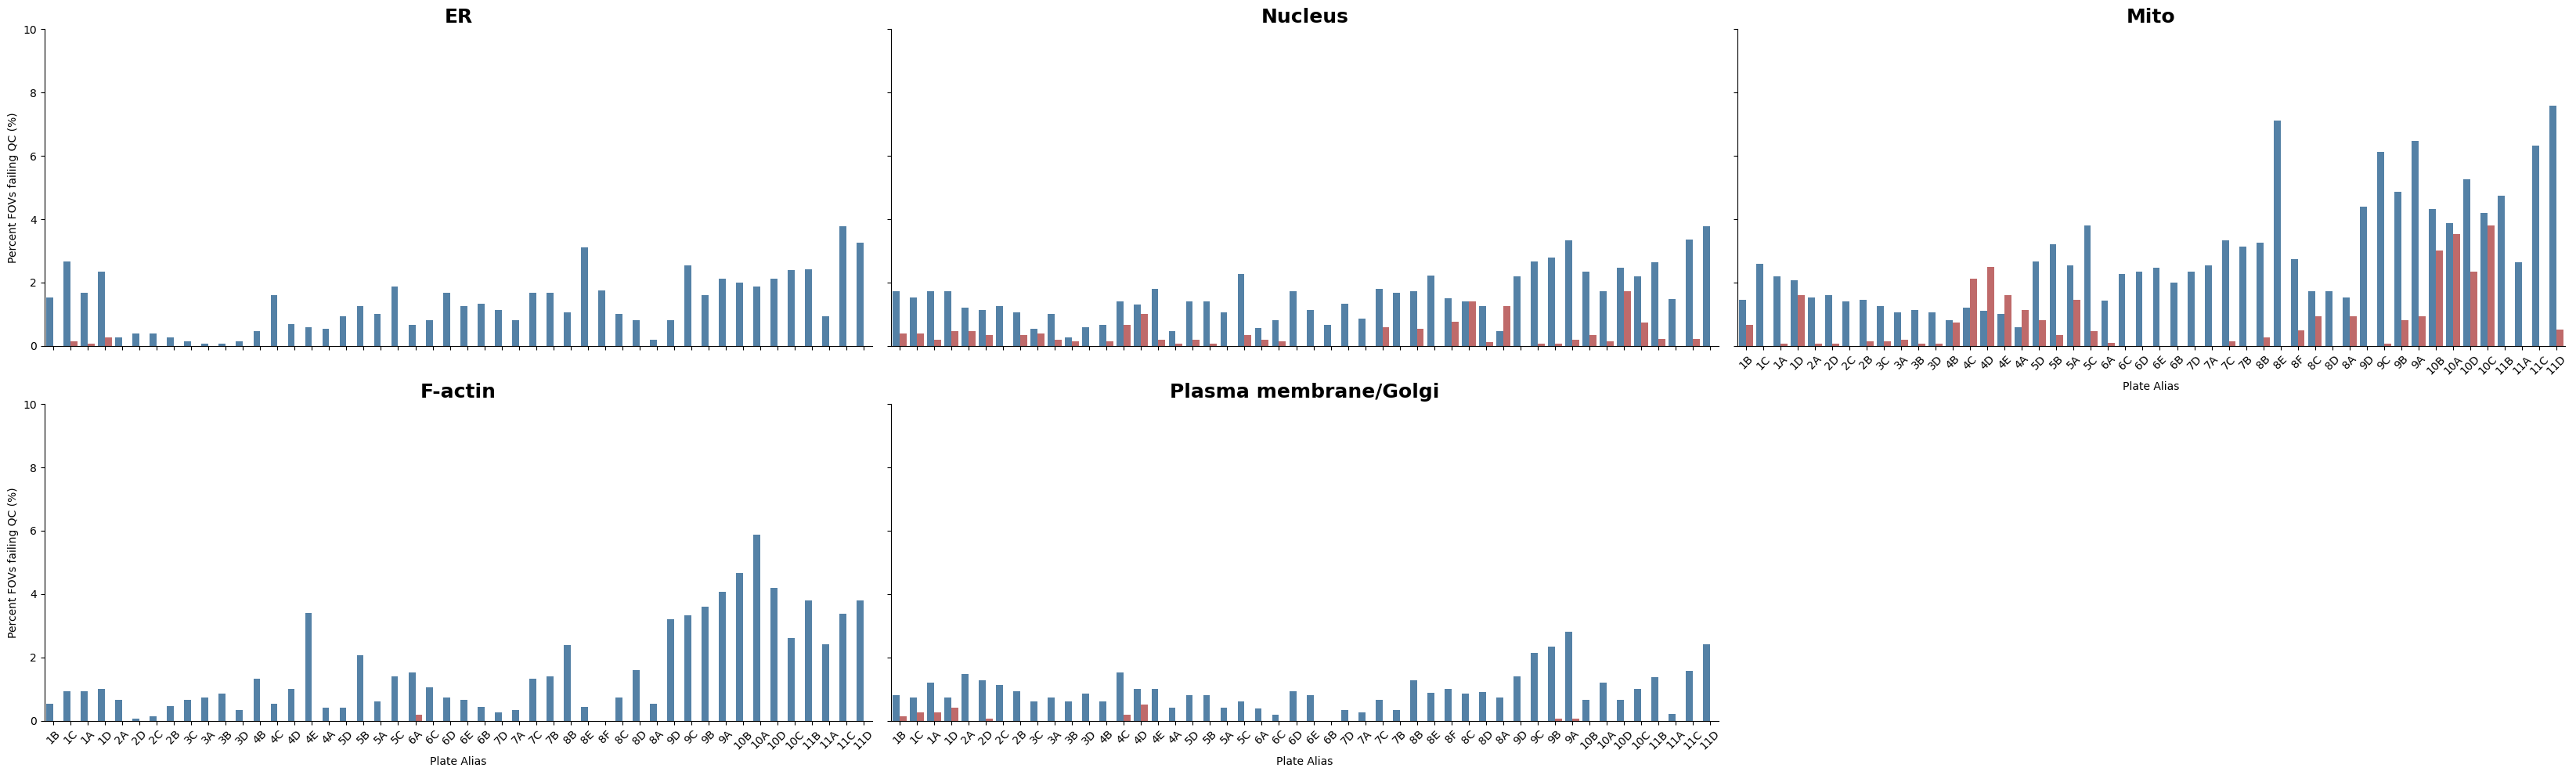

In [7]:
channels = ["OrigActin", "OrigDNA", "OrigER", "OrigMito", "OrigPM"]
channel_names = {
    "OrigActin": "F-actin",
    "OrigMito": "Mito",
    "OrigER": "ER",
    "OrigPM": "Plasma membrane/Golgi",
    "OrigDNA": "Nucleus",
}

summary_list = []

for ch in channels:
    # Use only the relevant columns to avoid the FutureWarning
    cols = ["blur_failed_channels", "sat_failed_channels"]
    temp = (
        qc_df.groupby("plate_alias")[cols]
        .apply(
            lambda g: pd.Series(
                {
                    "total_images": len(g),
                    "failed_blur": g["blur_failed_channels"].str.contains(ch).sum(),
                    "failed_sat": g["sat_failed_channels"].str.contains(ch).sum(),
                }
            )
        )
        .reset_index()
    )
    temp["channel"] = ch
    temp["percent_blur_failed"] = temp["failed_blur"] / temp["total_images"] * 100
    temp["percent_sat_failed"] = temp["failed_sat"] / temp["total_images"] * 100
    summary_list.append(temp)

fail_summary_ch = pd.concat(summary_list, ignore_index=True)

# Sort plate_alias numerically
fail_summary_ch = fail_summary_ch.sort_values(
    by="plate_alias", key=lambda x: x.str.extract(r"(\d+)").iloc[:, 0].astype(int)
)

# Melt for plotting
plot_df_ch = fail_summary_ch.melt(
    id_vars=["plate_alias", "channel"],
    value_vars=["percent_blur_failed", "percent_sat_failed"],
    var_name="QC_type",
    value_name="percent_failed",
)
plot_df_ch["QC_type"] = plot_df_ch["QC_type"].map(
    {
        "percent_blur_failed": "Blur < Threshold",
        "percent_sat_failed": "Saturation > 0.1",
    }
)

# Faceted bar plot per channel without legend
g = sns.catplot(
    data=plot_df_ch,
    x="plate_alias",
    y="percent_failed",
    hue="QC_type",
    col="channel",
    kind="bar",
    palette=["steelblue", "indianred"],
    col_wrap=3,
    height=5,
    aspect=2.2,
    legend=False,
)

# Axis labels
g.set_axis_labels("Plate Alias", "Percent FOVs failing QC (%)")
g.set(ylim=(0, 10))

# Rotate x-axis labels and set correct channel titles
for ax in g.axes.flatten():
    ax.tick_params(axis="x", rotation=45)
    # Get the facet's actual channel from the axis title
    orig_title = ax.get_title()  # e.g., 'channel = OrigActin'
    orig_channel = orig_title.split(" = ")[-1]
    # Set nicer title
    ax.set_title(
        channel_names.get(orig_channel, orig_channel), fontsize=18, weight="bold"
    )

plt.tight_layout()
plt.savefig(output_directory / "qc_failure_by_channel.png", dpi=600)
plt.show()